In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules


import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
path = kagglehub.dataset_download("vijayuv/onlineretail")
file_path = path + "/OnlineRetail.csv"

df = pd.read_csv(file_path, encoding='ISO-8859-1')

print("First 5 records:", df.head())

First 5 records:   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
df.drop_duplicates(inplace=True)

df.dropna(axis=0, subset=['InvoiceNo', 'Description'], inplace=True)

df = df[~df['InvoiceNo'].str.contains('C', na=False)]

df['Description'] = df['Description'].str.strip()

df = df[df['Quantity'] > 0]


In [10]:
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
        .sum().unstack().reset_index().fillna(0)
        .set_index('InvoiceNo'))

basket_sets = basket.applymap(encode_units)

frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)


rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules = rules.sort_values(['confidence', 'lift'], ascending=[False, False])

C:\Users\meral\AppData\Local\Temp\ipykernel_8328\1109787303.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)
c:\Users\meral\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [16]:
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                            antecedents                        consequents  \
3      (PINK REGENCY TEACUP AND SAUCER)  (GREEN REGENCY TEACUP AND SAUCER)   
4     (GREEN REGENCY TEACUP AND SAUCER)  (ROSES REGENCY TEACUP AND SAUCER)   
5     (ROSES REGENCY TEACUP AND SAUCER)  (GREEN REGENCY TEACUP AND SAUCER)   
6             (JUMBO BAG PINK POLKADOT)          (JUMBO BAG RED RETROSPOT)   
0          (ALARM CLOCK BAKELIKE GREEN)         (ALARM CLOCK BAKELIKE RED)   
2     (GREEN REGENCY TEACUP AND SAUCER)   (PINK REGENCY TEACUP AND SAUCER)   
10             (JUMBO STORAGE BAG SUKI)          (JUMBO BAG RED RETROSPOT)   
1            (ALARM CLOCK BAKELIKE RED)       (ALARM CLOCK BAKELIKE GREEN)   
9   (JUMBO SHOPPER VINTAGE RED PAISLEY)          (JUMBO BAG RED RETROSPOT)   
13            (LUNCH BAG  BLACK SKULL.)          (LUNCH BAG RED RETROSPOT)   

     support  confidence       lift  
3   0.030713    0.826371  16.779804  
4   0.037263    0.756650  14.629045  
5   0.037263    0.720450  1

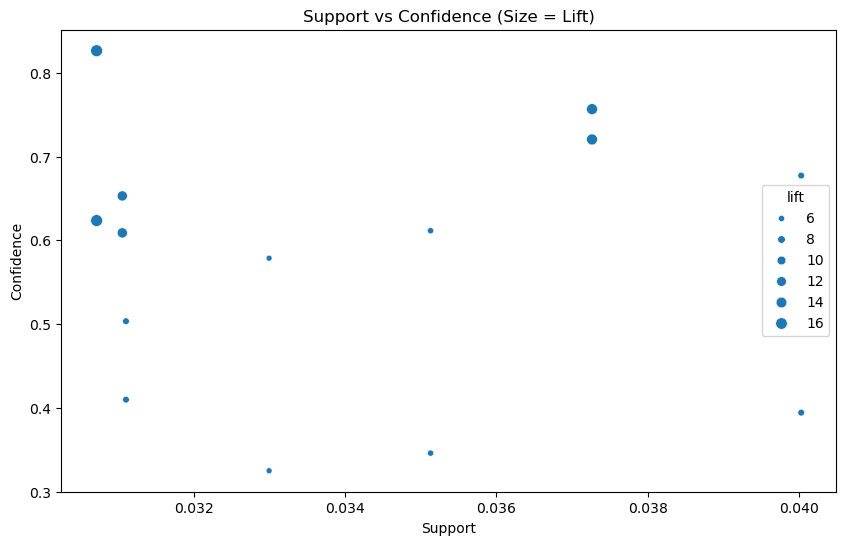

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", data=rules)
plt.title('Support vs Confidence (Size = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

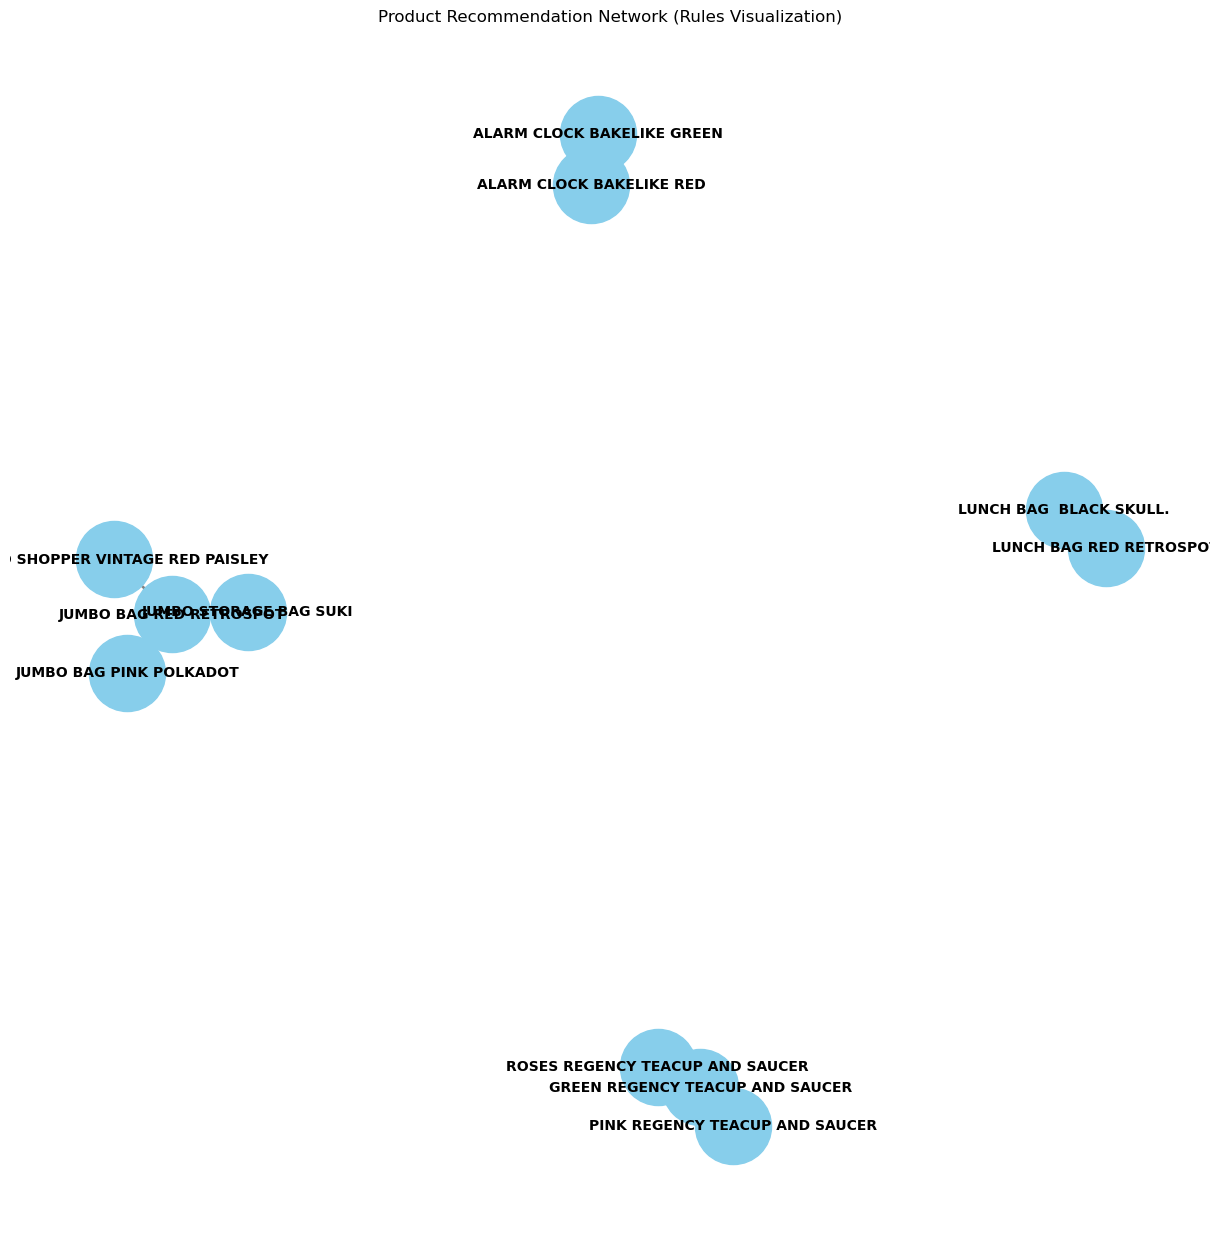

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

sub_rules = rules.head(30)

G = nx.DiGraph()


for i, row in sub_rules.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5) 

nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=3000, edge_color='gray', linewidths=1, 
        font_size=10, font_weight='bold', arrows=True)

plt.title('Product Recommendation Network (Rules Visualization)')
plt.show()